<a href="https://colab.research.google.com/github/keermani006/MACHINE-LEARNING/blob/main/LAB-2/ML_LAB_2_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Logistic Regression to Predict Graduate Admissions

## Objectives

To build a Logistic Regression model to predict admission of students to a graduate program using the variables: GRE score, GPA, and college prestige.

## Dependent Variable

Admission (`admit`)

- 0 = Not admitted
- 1 = Admitted

## Independent Variables

- GRE Score
- GPA
- College Prestige

## Machine Learning Algorithm

Logistic Regression

In [ ]:
# ============================================
# 1. IMPORT REQUIRED LIBRARIES
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# ============================================
# 2. LOAD THE DATASET
# ============================================

url = "https://stats.idre.ucla.edu/stat/stata/dae/binary.dta"

df = pd.read_stata(url)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [ ]:
# ============================================
# 3. DISPLAY THE DATASET
# ============================================

df.head()

,admit,gre,gpa,rank
0,0.0,380.0,3.61,3.0
1,1.0,660.0,3.67,3.0
2,1.0,800.0,4.00,1.0
3,1.0,640.0,3.19,4.0
4,0.0,520.0,2.93,4.0


In [ ]:
# ============================================
# 4. CHECK DATASET DIMENSIONS
# ============================================

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 400
Number of columns: 4


In [ ]:
# ============================================
# 5. DISPLAY COLUMN NAMES
# ============================================

print("Column names:")
print(df.columns.tolist())

Column names:
['admit', 'gre', 'gpa', 'rank']


In [ ]:
# ============================================
# 6. CHECK DATASET INFORMATION
# ============================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   admit   400 non-null    float32
 1   gre     400 non-null    float32
 2   gpa     400 non-null    float32
 3   rank    400 non-null    float32
dtypes: float32(4)
memory usage: 6.4 KB


In [ ]:
# ============================================
# 7. STATISTICAL SUMMARY
# ============================================

df.describe()

,admit,gre,gpa,rank
count,400.000000,400.000000,400.000000,400.000000
mean,0.317500,587.700012,3.389900,2.485000
std,0.466087,115.516663,0.380567,0.944462
min,0.000000,220.000000,2.260000,1.000000
25%,0.000000,520.000000,3.130000,2.000000
50%,0.000000,580.000000,3.395000,2.000000
75%,1.000000,660.000000,3.670000,3.000000
max,1.000000,800.000000,4.000000,4.000000


In [ ]:
# ============================================
# 8. CHECK FOR MISSING VALUES
# ============================================

print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
admit    0
gre      0
gpa      0
rank     0
dtype: int64


In [ ]:
# ============================================
# 9. CHECK ADMISSION VALUES
# ============================================

print("Unique admission values:")
print(df["admit"].unique())

print("\nAdmission counts:")
print(df["admit"].value_counts())

Unique admission values:
[0. 1.]

Admission counts:
admit
0.0    273
1.0    127
Name: count, dtype: int64


In [ ]:
# ============================================
# 10. CHECK RANK VALUES
# ============================================

print("Unique rank values:")
print(df["rank"].unique())

print("\nRank value counts:")
print(df["rank"].value_counts().sort_index())

Unique rank values:
[3. 1. 4. 2.]

Rank value counts:
rank
1.0     61
2.0    151
3.0    121
4.0     67
Name: count, dtype: int64


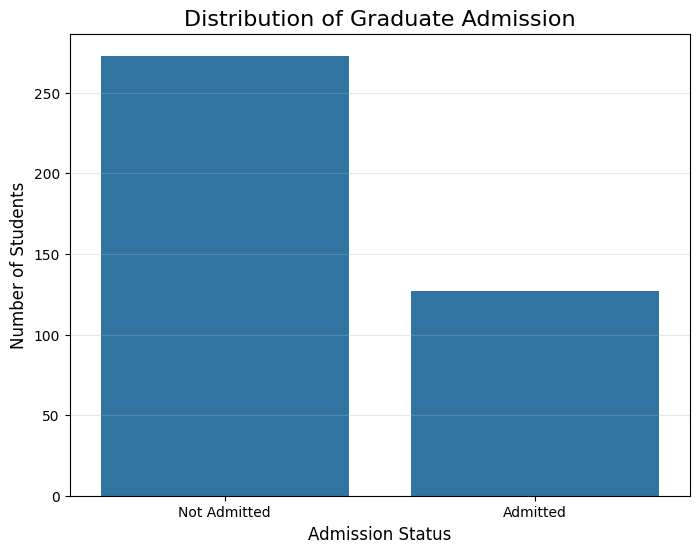

In [ ]:
# ============================================
# 11. ADMISSION DISTRIBUTION
# ============================================

plt.figure(figsize=(8, 6))

sns.countplot(
    data=df,
    x="admit"
)

plt.xlabel("Admission Status", fontsize=12)
plt.ylabel("Number of Students", fontsize=12)

plt.title(
    "Distribution of Graduate Admission",
    fontsize=16
)

plt.xticks(
    [0, 1],
    ["Not Admitted", "Admitted"]
)

plt.grid(axis="y", alpha=0.3)

plt.show()

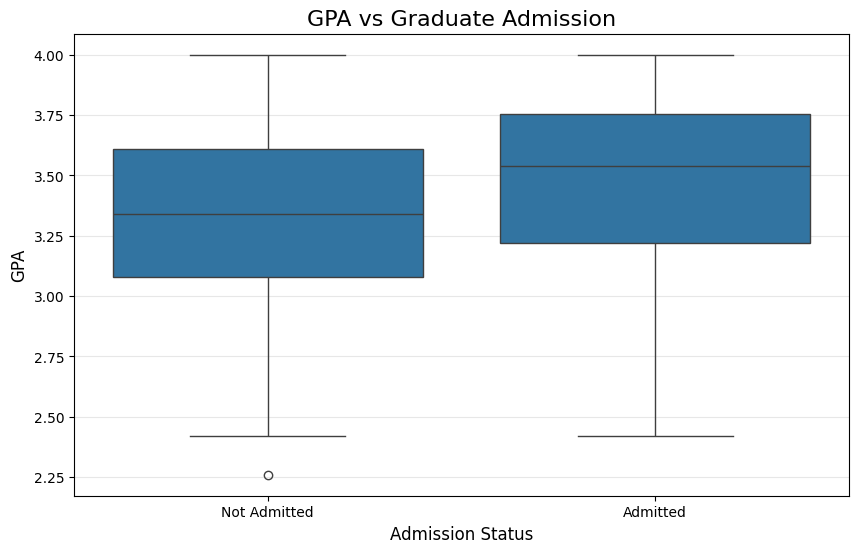

In [ ]:
# ============================================
# 12. GPA VS ADMISSION
# ============================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="admit",
    y="gpa"
)

plt.xlabel("Admission Status", fontsize=12)
plt.ylabel("GPA", fontsize=12)

plt.title(
    "GPA vs Graduate Admission",
    fontsize=16
)

plt.xticks(
    [0, 1],
    ["Not Admitted", "Admitted"]
)

plt.grid(axis="y", alpha=0.3)

plt.show()

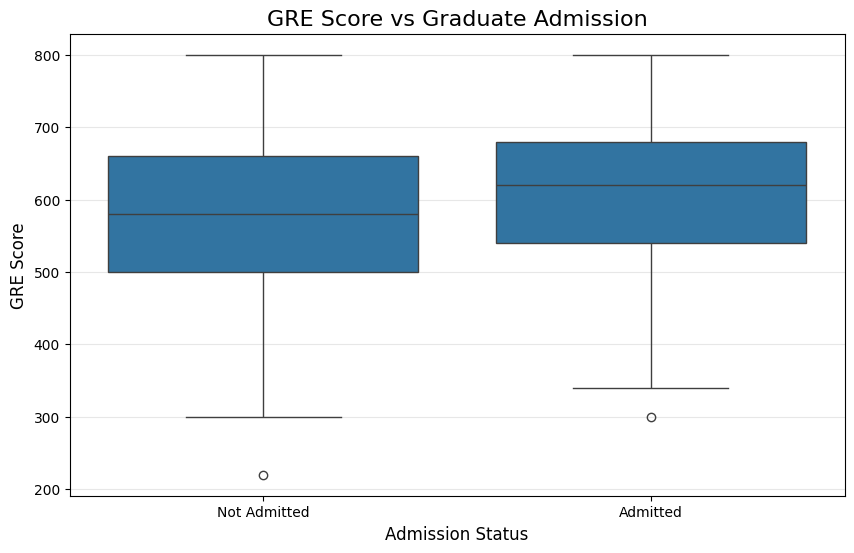

In [ ]:
# ============================================
# 13. GRE SCORE VS ADMISSION
# ============================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="admit",
    y="gre"
)

plt.xlabel("Admission Status", fontsize=12)
plt.ylabel("GRE Score", fontsize=12)

plt.title(
    "GRE Score vs Graduate Admission",
    fontsize=16
)

plt.xticks(
    [0, 1],
    ["Not Admitted", "Admitted"]
)

plt.grid(axis="y", alpha=0.3)

plt.show()

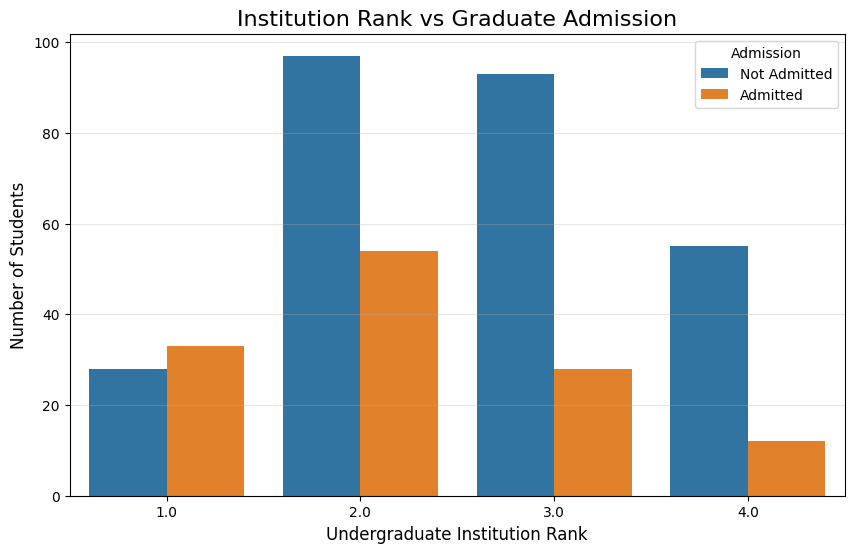

In [ ]:
# ============================================
# 14. RANK VS ADMISSION
# ============================================

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="rank",
    hue="admit"
)

plt.xlabel(
    "Undergraduate Institution Rank",
    fontsize=12
)

plt.ylabel(
    "Number of Students",
    fontsize=12
)

plt.title(
    "Institution Rank vs Graduate Admission",
    fontsize=16
)

plt.legend(
    title="Admission",
    labels=["Not Admitted", "Admitted"]
)

plt.grid(axis="y", alpha=0.3)

plt.show()

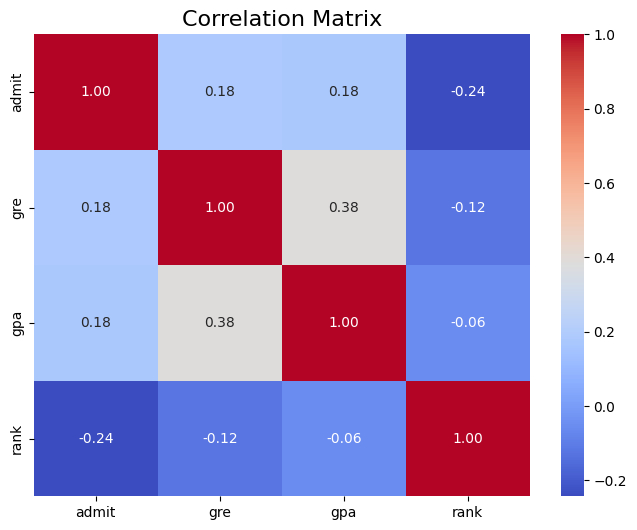

In [ ]:
# ============================================
# 15. CORRELATION MATRIX
# ============================================

plt.figure(figsize=(8, 6))

sns.heatmap(
    df[["admit", "gre", "gpa", "rank"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Correlation Matrix",
    fontsize=16
)

plt.show()

In [ ]:
# ============================================
# 16. DEFINE FEATURES AND TARGET
# ============================================

X = df[["gre", "gpa", "rank"]]

y = df["admit"]

print("Independent Variables:")
print(X.head())

print("\nDependent Variable:")
print(y.head())

Independent Variables:
     gre   gpa  rank
0  380.0  3.61   3.0
1  660.0  3.67   3.0
2  800.0  4.00   1.0
3  640.0  3.19   4.0
4  520.0  2.93   4.0

Dependent Variable:
0    0.0
1    1.0
2    1.0
3    1.0
4    0.0
Name: admit, dtype: float32


In [ ]:
# ============================================
# 17. SPLIT THE DATASET
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 320
Testing samples: 80


In [ ]:
# ============================================
# 18. CREATE LOGISTIC REGRESSION MODEL
# ============================================

model = LogisticRegression()

model.fit(
    X_train,
    y_train
)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [ ]:
# ============================================
# 19. DISPLAY MODEL COEFFICIENTS
# ============================================

print("Intercept:", model.intercept_[0])

print("\nCoefficients:")

for feature, coefficient in zip(X.columns, model.coef_[0]):
    print(feature, ":", coefficient)

Intercept: -3.6412540111454885

Coefficients:
gre : 0.0022572482013862964
gpa : 0.7672912334670341
rank : -0.4569695700999185


In [ ]:
# ============================================
# 21. PREDICT ADMISSION PROBABILITIES
# ============================================

y_probability = model.predict_proba(X_test)[:, 1]

print("Predicted probability of admission:")
print(y_probability)

Predicted probability of admission:
[0.22475487 0.33649819 0.31325743 0.12641903 0.30028149 0.42670118
 0.3266478  0.35612589 0.16613802 0.33038374 0.4847465  0.38757628
 0.17839979 0.23685403 0.15114289 0.21169588 0.32833769 0.2937216
 0.44980388 0.1592373  0.31645289 0.37478223 0.18454468 0.1440498
 0.33236121 0.43226054 0.22018429 0.18259219 0.40129639 0.53691292
 0.52349407 0.37036047 0.43226054 0.19527823 0.39714815 0.28600858
 0.22513023 0.23040037 0.09977153 0.4103317  0.17299701 0.13445178
 0.23205231 0.25329023 0.44910055 0.32320936 0.26188574 0.25989567
 0.5361146  0.28310746 0.25941265 0.28944562 0.27670072 0.37511627
 0.25958415 0.53287314 0.306728   0.29844408 0.40964414 0.34221535
 0.41817188 0.25752939 0.11775842 0.20673868 0.18444096 0.49964135
 0.17907906 0.34741561 0.20368533 0.49134863 0.25013292 0.15091401
 0.55315016 0.44358459 0.31471793 0.25538552 0.33781405 0.20632691
 0.31861792 0.29139468]


In [ ]:
# ============================================
# 22. COMPARE ACTUAL AND PREDICTED VALUES
# ============================================

y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual Admission": y_test.values,
    "Predicted Admission": y_pred,
    "Admission Probability": y_probability
})

comparison

,Actual Admission,Predicted Admission,Admission Probability
0,0.0,0.0,0.224755
1,0.0,0.0,0.336498
2,0.0,0.0,0.313257
3,0.0,0.0,0.126419
4,1.0,0.0,0.300281
...,...,...,...
75,0.0,0.0,0.255386
76,0.0,0.0,0.337814
77,0.0,0.0,0.206327
78,1.0,0.0,0.318618


In [ ]:
# ============================================
# 23. CALCULATE MODEL ACCURACY
# ============================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy:",
    round(accuracy * 100, 2),
    "%"
)

Accuracy: 72.5 %


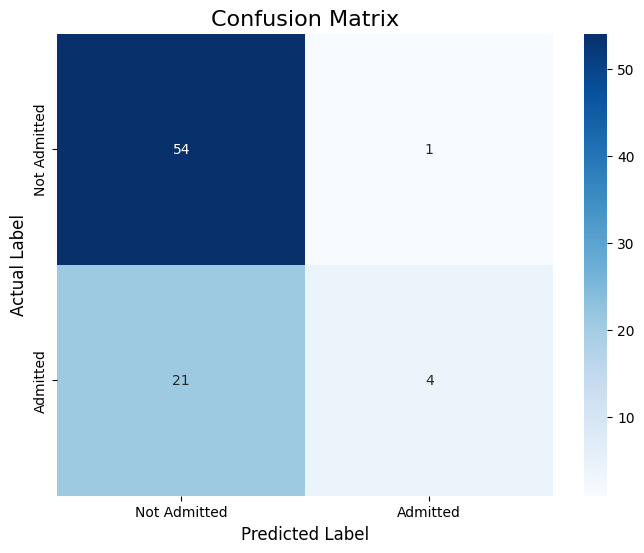

In [ ]:
# ============================================
# 24. CONFUSION MATRIX
# ============================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Admitted", "Admitted"],
    yticklabels=["Not Admitted", "Admitted"]
)

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("Actual Label", fontsize=12)

plt.title(
    "Confusion Matrix",
    fontsize=16
)

plt.show()

In [ ]:
# ============================================
# 25. CLASSIFICATION REPORT
# ============================================

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Not Admitted", "Admitted"]
    )
)

              precision    recall  f1-score   support

Not Admitted       0.72      0.98      0.83        55
    Admitted       0.80      0.16      0.27        25

    accuracy                           0.72        80
   macro avg       0.76      0.57      0.55        80
weighted avg       0.74      0.72      0.65        80



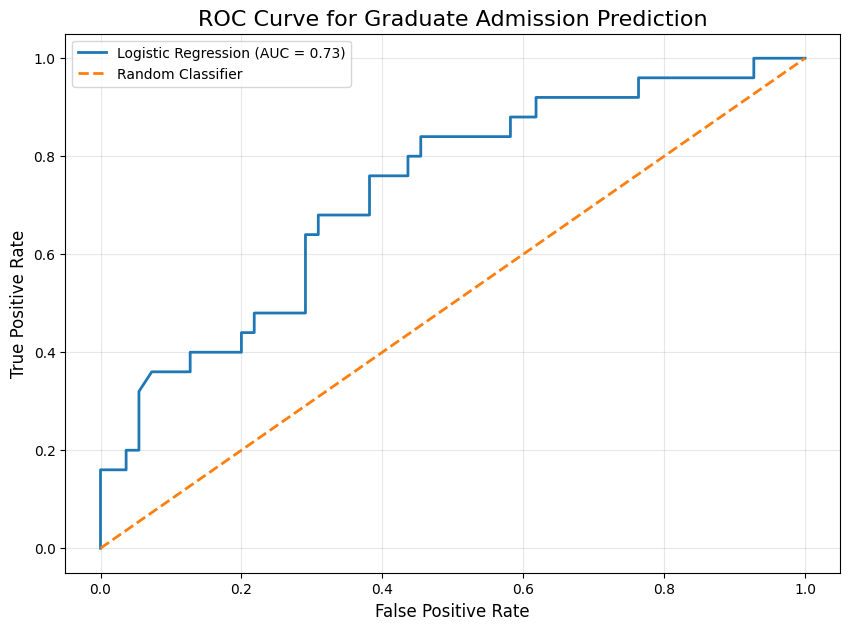

In [ ]:
# ============================================
# 26. ROC CURVE
# ============================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

auc_score = roc_auc_score(
    y_test,
    y_probability
)

plt.figure(figsize=(10, 7))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Logistic Regression (AUC = {auc_score:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    label="Random Classifier"
)

plt.xlabel(
    "False Positive Rate",
    fontsize=12
)

plt.ylabel(
    "True Positive Rate",
    fontsize=12
)

plt.title(
    "ROC Curve for Graduate Admission Prediction",
    fontsize=16
)

plt.legend()

plt.grid(True, alpha=0.3)

plt.show()

In [ ]:
# ============================================
# 27. CALCULATE AUC SCORE
# ============================================

print(
    "ROC-AUC Score:",
    round(auc_score, 4)
)

ROC-AUC Score: 0.7269


In [ ]:
# ============================================
# 28. MODEL EVALUATION SUMMARY
# ============================================

print("============================================")
print("MODEL EVALUATION")
print("============================================")

print(
    "Accuracy:",
    round(accuracy * 100, 2),
    "%"
)

print(
    "ROC-AUC Score:",
    round(auc_score, 4)
)

print("============================================")

MODEL EVALUATION
Accuracy: 72.5 %
ROC-AUC Score: 0.7269


In [ ]:
# ============================================
# 29. PREDICT ADMISSION FOR A NEW STUDENT
# ============================================

new_student = pd.DataFrame({
    "gre": [320],
    "gpa": [3.7],
    "rank": [2]
})

predicted_class = model.predict(new_student)[0]

admission_probability = model.predict_proba(
    new_student
)[0][1]

print(
    "Admission Probability:",
    round(admission_probability * 100, 2),
    "%"
)

if predicted_class == 1:
    print("Prediction: ADMITTED")
else:
    print("Prediction: NOT ADMITTED")

Admission Probability: 27.01 %
Prediction: NOT ADMITTED


In [ ]:
# ============================================
# 30. FINAL MODEL RESULTS
# ============================================

print("============================================")
print("FINAL MODEL RESULTS")
print("============================================")

print("Model: Logistic Regression")

print(
    "Accuracy:",
    round(accuracy * 100, 2),
    "%"
)

print(
    "ROC-AUC Score:",
    round(auc_score, 4)
)

print("============================================")

FINAL MODEL RESULTS
Model: Logistic Regression
Accuracy: 72.5 %
ROC-AUC Score: 0.7269


# Conclusion

Logistic Regression model has been created for prediction of graduate school admission depending on the GRE score, GPA, and institution rank.

The `admit` feature has been used as the target feature where 0 denotes not admitted and 1 denotes admitted. The features used are GRE score, GPA, and institution rank.

The data has been explored and checked for missing values before splitting into training and test datasets. After that, the Logistic Regression model has been created to predict admission class and probability of admission.

Model evaluation has been performed by accuracy, confusion matrix, classification report, and ROC-AUC score.

The created model can be used to predict the probability of admission for a new student depending on their GRE score, GPA, and institution rank.

Therefore, Logistic Regression is appropriate for this case study.